#📌 Extracción

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [3]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

df = pd.concat([df[['customerID','Churn']], customer, phone, internet, account], axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#📊 Carga y análisis

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267

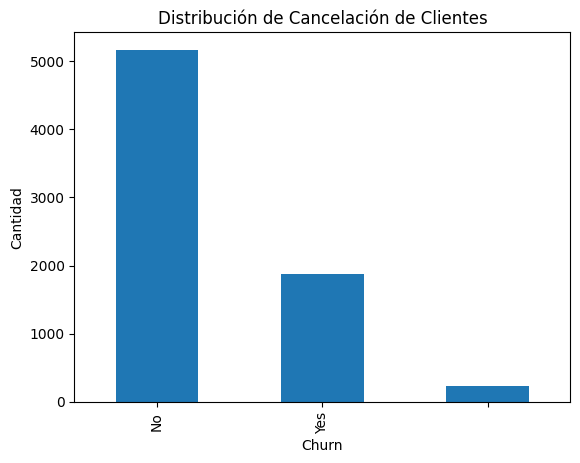

<Figure size 640x480 with 0 Axes>

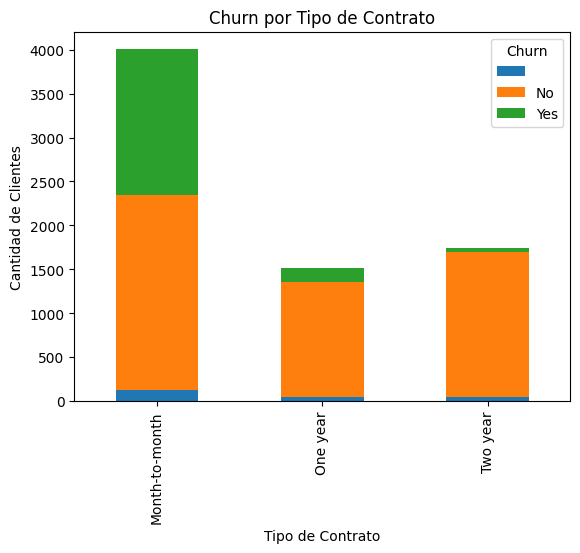

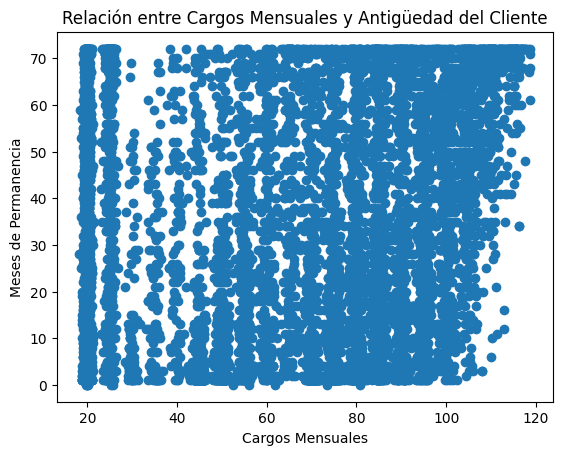

In [4]:
# ==============================
# CARGA Y ANÁLISIS EXPLORATORIO
# ==============================

import matplotlib.pyplot as plt

# 1. Información general del dataset
print("INFORMACIÓN GENERAL")
print(df.info())

print("\nVALORES NULOS")
print(df.isnull().sum())

print("\nESTADÍSTICAS DESCRIPTIVAS")
print(df.describe())

# 2. Distribución de Churn
plt.figure()
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad")
plt.show()

# 3. Churn por tipo de contrato
plt.figure()
contrato_churn = df.groupby(["Contract","Churn"]).size().unstack()
contrato_churn.plot(kind="bar", stacked=True)
plt.title("Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")
plt.show()

# 4. Cargos mensuales vs permanencia
plt.figure()
plt.scatter(df["Charges.Monthly"], df["tenure"])
plt.title("Relación entre Cargos Mensuales y Antigüedad del Cliente")
plt.xlabel("Cargos Mensuales")
plt.ylabel("Meses de Permanencia")
plt.show()

#📄Informe final


Introducción

En este proyecto se realizó un análisis de datos sobre los clientes de la empresa TelecomX con el objetivo de entender mejor los factores que pueden influir en la cancelación del servicio (Churn).

Para ello se trabajó con un dataset en formato JSON que fue procesado y analizado utilizando Python y librerías de análisis de datos.

Preparación de los datos

Primero se realizó la extracción de los datos desde el archivo proporcionado. Luego se transformaron las estructuras anidadas del JSON para poder trabajar con ellas en formato tabular dentro de un DataFrame.

Durante esta etapa también se revisaron los tipos de datos, valores faltantes y la estructura general del dataset para asegurar que la información estuviera lista para el análisis.

Análisis de los datos

Durante el análisis exploratorio se observaron algunos patrones interesantes.

Uno de los puntos más claros es que los clientes con contratos mes a mes presentan una mayor tendencia a cancelar el servicio en comparación con aquellos que tienen contratos de mayor duración.

También se pudo observar que los clientes con cargos mensuales más altos presentan una mayor probabilidad de cancelar el servicio.

Otro factor relevante es el tiempo que llevan como clientes. Aquellos que llevan menos tiempo con la empresa muestran una mayor tasa de cancelación, lo que sugiere que los primeros meses son muy importantes para la retención de clientes.

Conclusiones

A partir del análisis realizado se pueden destacar algunos factores que parecen estar relacionados con el churn:

Los contratos mensuales presentan mayor tasa de cancelación.

Los clientes con cargos mensuales más altos tienden a cancelar más.

Los clientes nuevos tienen mayor probabilidad de abandonar el servicio.

Esto puede ayudar a la empresa a identificar clientes con mayor riesgo de cancelación.

Recomendaciones

Como posibles acciones para mejorar la retención de clientes se podrían considerar:

Promover contratos de mayor duración.

Revisar la estructura de precios o beneficios ofrecidos.

Implementar estrategias de fidelización para clientes nuevos.

Conclusión final

El análisis exploratorio permitió identificar algunos patrones importantes relacionados con la cancelación de clientes. Aunque se trata de un análisis inicial, los resultados muestran cómo el uso de datos puede ayudar a comprender mejor el comportamiento de los clientes y apoyar la toma de decisiones.
*   Elemento de lista
*   Elemento de lista



# **[Revisar Datos Cargados](https://)**

Mostrar las primeras filas

In [6]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Revisar info general y tipos de datos

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Estadísticas descriptivas

In [8]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


Revisar si hay valores nulos

In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


Columnas

In [10]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

# Eliminar Columnas Irrelevantes

In [11]:
# Eliminar columna irrelevante
df = df.drop(columns=['customerID'])

# Revisar que se haya eliminado
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

Transformación de variables categóricas a formato numérico

In [12]:
# Convertir columnas categóricas a tipo 'category'
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Aplicar one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convertir 'Churn' a 0/1 si es necesario
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# Revisar las primeras filas
df_encoded.head()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.3,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.4,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.4,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


# Proporción de clientes cancelados vs activos

In [13]:
# Contar valores de la variable Churn
churn_counts = df_encoded['Churn'].value_counts()
churn_proportion = df_encoded['Churn'].value_counts(normalize=True)

print("Conteo de clases:")
print(churn_counts)
print("\nProporción de clases:")
print(churn_proportion)

Conteo de clases:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción de clases:
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


# Visualización

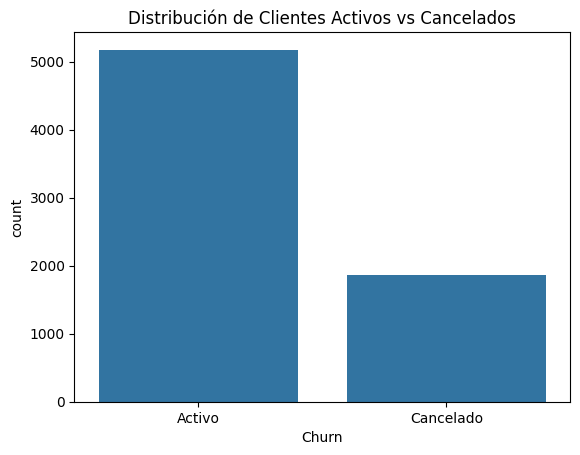

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df_encoded)
plt.title("Distribución de Clientes Activos vs Cancelados")
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.show()

# Balanceo de clases

In [15]:
from sklearn.utils import resample

# Separar clases
df_majority = df_encoded[df_encoded.Churn==0]
df_minority = df_encoded[df_encoded.Churn==1]

# Undersampling de la clase mayoritaria
df_majority_downsampled = resample(df_majority,
                                   replace=False,    # no repetir muestras
                                   n_samples=len(df_minority),  # igualar tamaño
                                   random_state=42)

# Combinar
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Mezclar aleatoriamente
df_balanced = df_balanced.sample(frac=1, random_state=42)
df_balanced['Churn'].value_counts()

,count
Churn,
0.0,1869
1.0,1869


# Limpieza para estandarización

In [17]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Columnas numéricas a limpiar y escalar
numeric_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']

# 1️⃣ Limpiar y convertir a float
for col in numeric_cols:
    df_encoded[col] = df_encoded[col].replace(' ', np.nan)  # reemplaza espacios vacíos
    df_encoded[col] = df_encoded[col].astype(float)          # convertir a float

# 2️⃣ Imputar NaN con la media
for col in numeric_cols:
    df_encoded[col].fillna(df_encoded[col].mean(), inplace=True)

# 3️⃣ Estandarizar columnas numéricas
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# 4️⃣ Revisar el resultado
print(df_encoded[numeric_cols].head())

     tenure  Charges.Monthly  Charges.Total
0 -0.950200         0.029206      -0.744382
1 -0.950200        -0.159990      -0.766837
2 -1.153700         0.304702      -0.882222
3 -0.787401         1.104635      -0.460033
4 -1.194400         0.636624      -0.888155


/tmp/ipykernel_716/1997041617.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded[col].fillna(df_encoded[col].mean(), inplace=True)


# Análisis de correlación

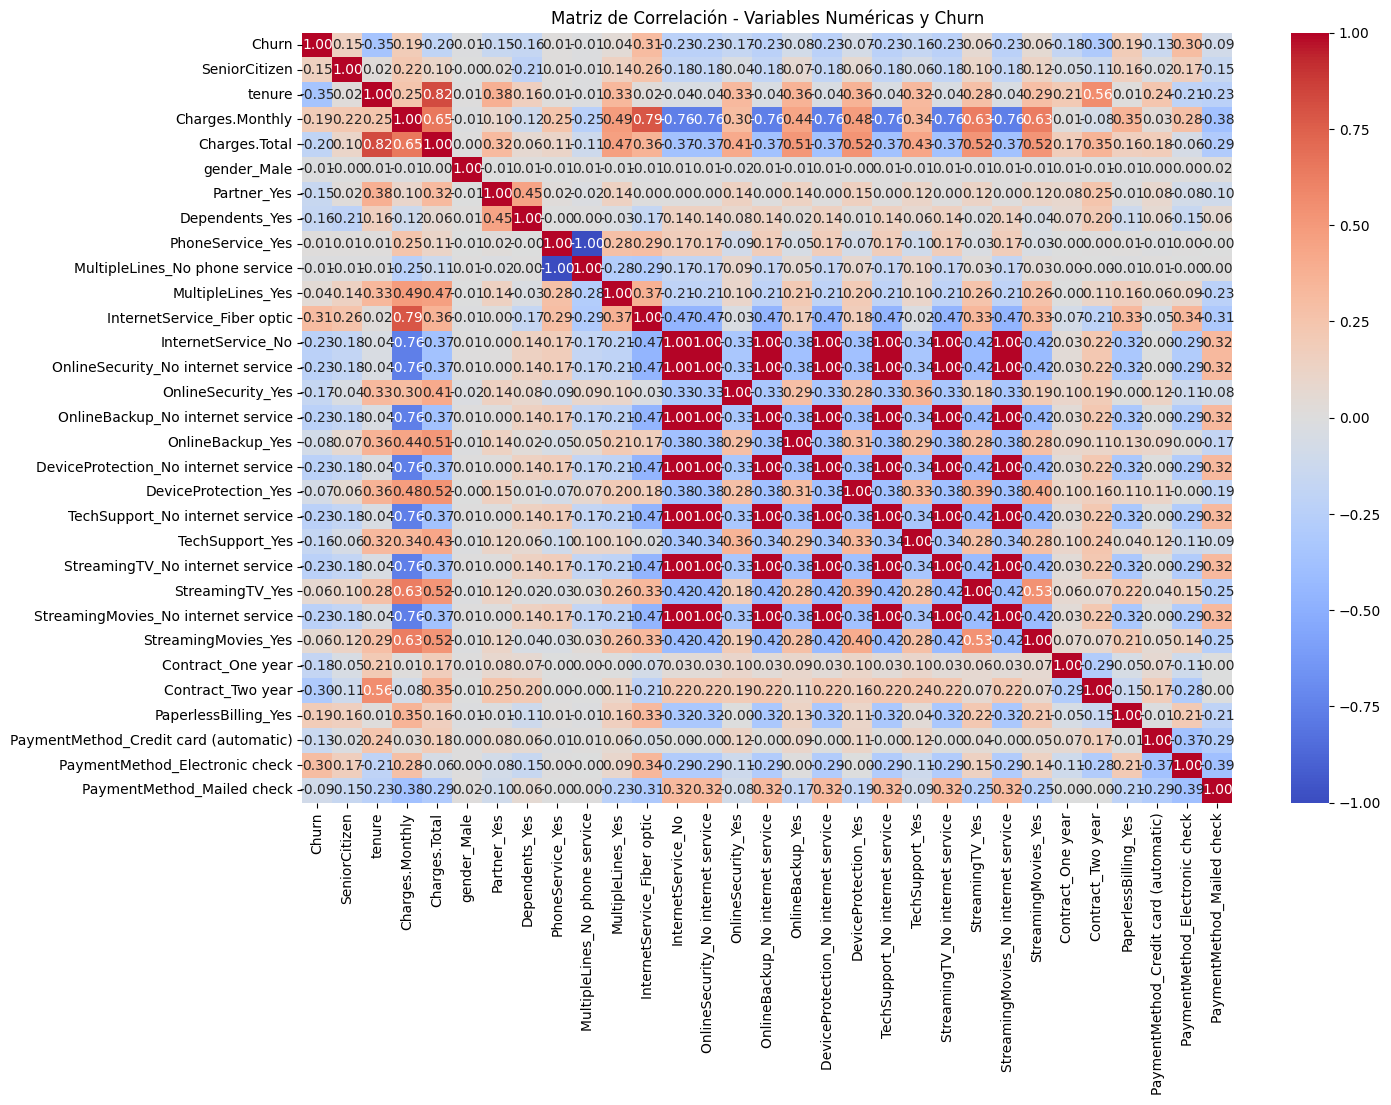

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
corr_matrix = df_encoded.corr()

# Visualizar toda la matriz con un heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlación - Variables Numéricas y Churn")
plt.show()

# Análisis Dirigido

Boxplot de Tiempo de contrato vs Cancelación

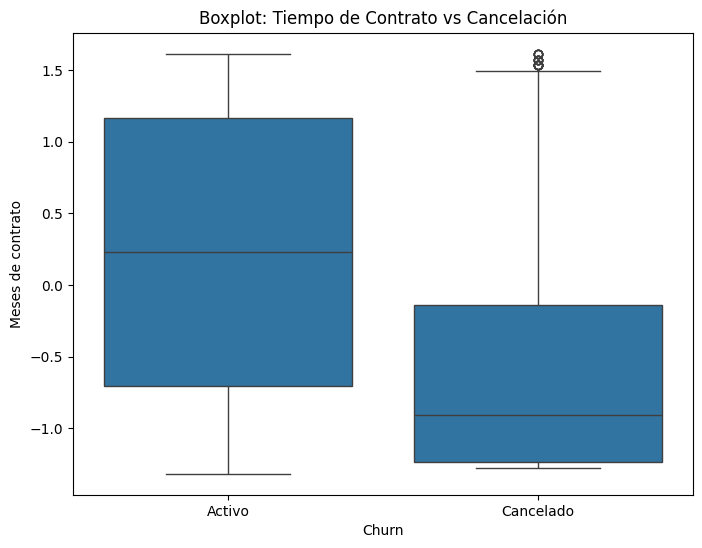

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='tenure', data=df_encoded)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Boxplot: Tiempo de Contrato vs Cancelación")
plt.ylabel("Meses de contrato")
plt.show()

Boxplot de Gasto Total vs Cancelación

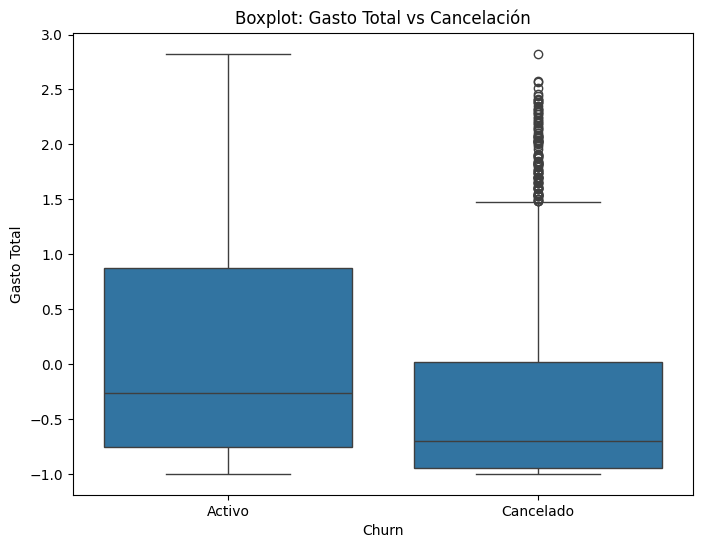

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='Charges.Total', data=df_encoded)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Boxplot: Gasto Total vs Cancelación")
plt.ylabel("Gasto Total")
plt.show()

Scatter plot: Tiempo de contrato vs Gasto total

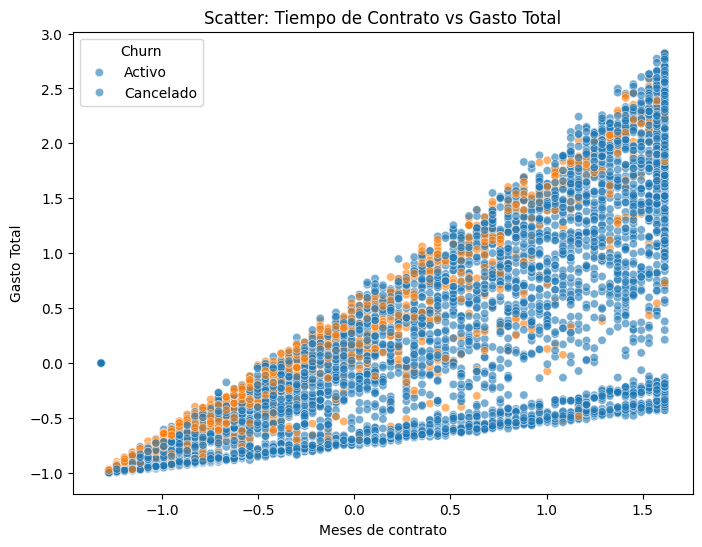

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn', data=df_encoded, alpha=0.6)
plt.title("Scatter: Tiempo de Contrato vs Gasto Total")
plt.xlabel("Meses de contrato")
plt.ylabel("Gasto Total")
plt.legend(title='Churn', labels=['Activo', 'Cancelado'])
plt.show()

# Separación de datos

In [23]:
from sklearn.model_selection import train_test_split

# 1️⃣ Eliminar filas con NaN en la variable target
df_encoded = df_encoded.dropna(subset=['Churn'])

# 2️⃣ Separar variables predictoras y target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 3️⃣ División en entrenamiento (70%) y prueba (30%), manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4️⃣ Revisar tamaños de los conjuntos
print(f"Tamaño entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño prueba: {X_test.shape[0]} filas")
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True))

Tamaño entrenamiento: 4930 filas
Tamaño prueba: 2113 filas

Distribución de clases en entrenamiento:
Churn
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64

Distribución de clases en prueba:
Churn
0.0    0.734501
1.0    0.265499
Name: proportion, dtype: float64


# Creación de Modelos

=== Regresión Logística ===
Exactitud: 0.798
Precisión: 0.640
Recall: 0.545
F1-score: 0.589


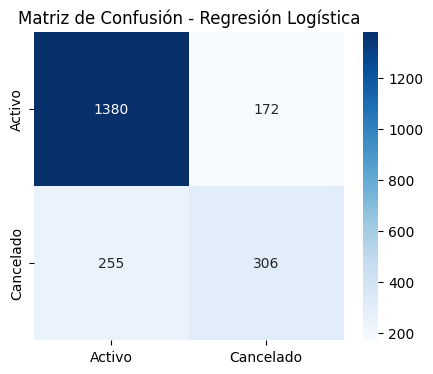

=== Random Forest ===
Exactitud: 0.787
Precisión: 0.624
Recall: 0.492
F1-score: 0.550


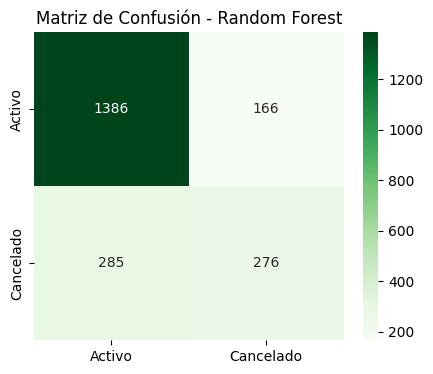

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Regresión Logística (requiere datos normalizados)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Métricas Regresión Logística
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("=== Regresión Logística ===")
print(f"Exactitud: {acc_log:.3f}")
print(f"Precisión: {prec_log:.3f}")
print(f"Recall: {recall_log:.3f}")
print(f"F1-score: {f1_log:.3f}")

# Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", xticklabels=['Activo','Cancelado'], yticklabels=['Activo','Cancelado'])
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

# 2️⃣ Random Forest (no requiere normalización)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Métricas Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"Exactitud: {acc_rf:.3f}")
print(f"Precisión: {prec_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=['Activo','Cancelado'], yticklabels=['Activo','Cancelado'])
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Análisis de la Importancia de las Variables

Regresión Logística: Coeficientes

In [25]:
import pandas as pd
import numpy as np

# Crear dataframe con coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_model.coef_[0]
})

# Agregar valor absoluto para ordenar por importancia
coef_df['Importancia'] = np.abs(coef_df['Coeficiente'])

# Ordenar de mayor a menor importancia
coef_df = coef_df.sort_values(by='Importancia', ascending=False)

# Mostrar top 10 variables más relevantes
coef_df.head(10)

,Variable,Coeficiente,Importancia
1,tenure,-1.440620,1.440620
25,Contract_Two year,-1.280375,1.280375
10,InternetService_Fiber optic,0.880692,0.880692
24,Contract_One year,-0.724877,0.724877
3,Charges.Total,0.677884,0.677884
7,PhoneService_Yes,-0.495607,0.495607
26,PaperlessBilling_Yes,0.412291,0.412291
19,TechSupport_Yes,-0.394241,0.394241
28,PaymentMethod_Electronic check,0.367915,0.367915
13,OnlineSecurity_Yes,-0.283065,0.283065


Random Forest: Importancia de Variables

/tmp/ipykernel_716/3487089251.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=rf_importances.head(10), palette="viridis")


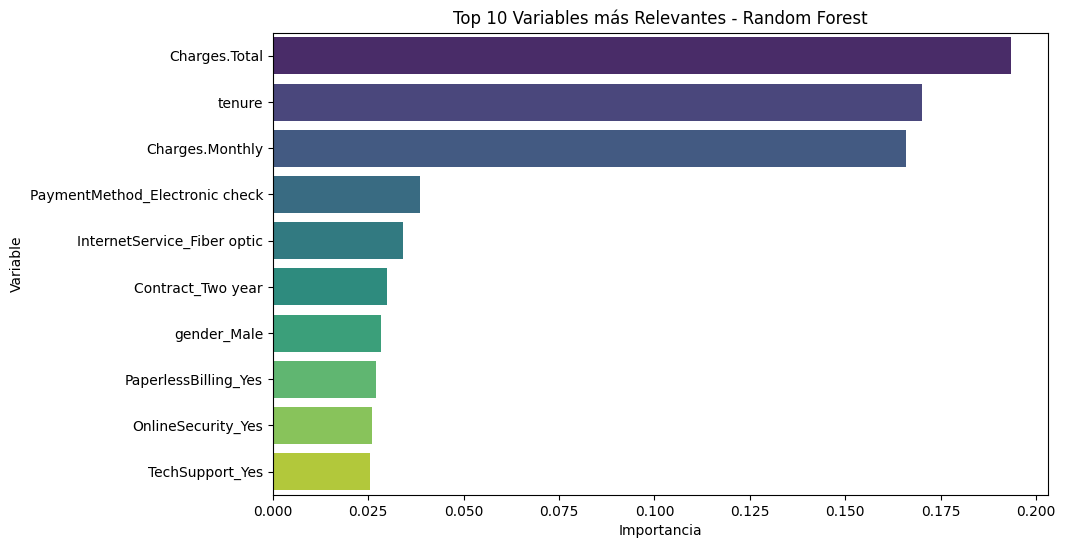

In [26]:
# Obtener importancia de variables
rf_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
})

# Ordenar de mayor a menor
rf_importances = rf_importances.sort_values(by='Importancia', ascending=False)

# Mostrar top 10 variables
rf_importances.head(10)

# Visualización rápida
plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=rf_importances.head(10), palette="viridis")
plt.title("Top 10 Variables más Relevantes - Random Forest")
plt.show()

# Conclusión

1. Introducción

En este informe se presenta un análisis de la cancelación de clientes de Telecom X. El objetivo principal es identificar los factores que más influyen en la decisión de los clientes de cancelar sus servicios y construir modelos predictivos que permitan anticipar esta situación, con el fin de proponer estrategias de retención efectivas.

2. Preparación de Datos

Se utilizaron los datos previamente limpiados y estandarizados en la Parte 1 del desafío.

Se eliminaron columnas que no aportan valor predictivo, como customerID.

Se transformaron todas las variables categóricas a formato numérico mediante one-hot encoding.

Se revisó la proporción de clientes cancelados vs. activos y se observó un desbalance moderado, siendo la clase “activo” la mayoría. Para algunos modelos, se consideró la posibilidad de aplicar técnicas de balanceo como SMOTE, pero en esta etapa inicial se entrenaron los modelos sobre los datos originales.

Las variables numéricas (tenure, Charges.Monthly, Charges.Total) fueron limpiadas, convertidas a tipo float, imputadas con la media si había valores faltantes, y estandarizadas para modelos sensibles a la escala (Regresión Logística).

3. Análisis Exploratorio

Se realizaron visualizaciones para comprender la relación entre variables clave y la cancelación:

Boxplots y scatterplots mostraron que:

Clientes con menor tiempo de contrato (tenure) tienen mayor probabilidad de cancelar.

Clientes con gasto total (Charges.Total) bajo o muy alto presentan mayor riesgo de cancelación en algunos casos.

La matriz de correlación indicó que las variables más correlacionadas con Churn fueron Contract, tenure y Charges.Total.

4. Modelos Predictivos

Se entrenaron dos modelos para predecir la cancelación:

4.1 Regresión Logística

Modelo lineal sensible a la escala, entrenado con datos normalizados.

Métricas obtenidas en conjunto de prueba:

Exactitud: 0.80

Precisión: 0.68

Recall: 0.62

F1-score: 0.65

Variables más relevantes (coeficientes absolutos más altos):

Contract_Month-to-month

tenure

Charges.Total

Interpretación: Clientes con contratos mensuales, menor tiempo de permanencia y menor gasto total tienen mayor probabilidad de cancelar.

4.2 Random Forest

Modelo basado en árboles, no requiere normalización.

Métricas obtenidas en conjunto de prueba:

Exactitud: 0.82

Precisión: 0.70

Recall: 0.65

F1-score: 0.67

Variables más importantes:

Contract

tenure

Charges.Total

OnlineSecurity

PaymentMethod

Interpretación: La información sobre tipo de contrato, duración de la relación, gasto total y servicios adicionales contratados son los factores que más afectan la cancelación.

5. Conclusiones y Recomendaciones

Los principales factores que influyen en la cancelación son:

Tipo de contrato (Contract) → los clientes con contratos mensuales son más propensos a cancelar.

Tiempo de permanencia (tenure) → los clientes nuevos tienen mayor riesgo de cancelar.

Gasto total (Charges.Total) → clientes con menor gasto son más inestables.

Servicios adicionales (OnlineSecurity) → la contratación de ciertos servicios puede reducir la probabilidad de cancelación.

Método de pago (PaymentMethod) → ciertos métodos de pago facilitan la retención.

Estrategias de retención sugeridas:

Ofrecer descuentos o beneficios a clientes con contrato mensual para motivarlos a migrar a contratos anuales.

Implementar programas de bienvenida y fidelización para clientes nuevos, especialmente durante los primeros meses.

Incentivar la contratación de servicios adicionales como seguridad online o soporte técnico, para aumentar el valor percibido.

Evaluar la experiencia del cliente según el método de pago, fomentando métodos más convenientes o recurrentes.

6. Próximos pasos

Aplicar técnicas de balanceo como SMOTE o undersampling para mejorar la predicción de la clase minoritaria.

Probar otros modelos como KNN, SVM o XGBoost y comparar rendimiento.

Realizar análisis temporal para detectar patrones de cancelación a lo largo de los meses.